# Bluestock Mutual Fund Analytics

This notebook is for cleaning mutual fund data, fixing date formats, and starting exploratory data analysis with charts.


In [2]:
!pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.0-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.5.0-cp314-cp314-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings


In [4]:

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)



In [5]:
root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
raw_dir = root / 'data' / 'raw'
processed_dir = root / 'data' / 'processed'

fund_master = pd.read_csv(processed_dir / 'cleaned_01_fund_master.csv')
nav_history = pd.read_csv(processed_dir / 'cleaned_02_nav_history.csv')

print('Fund master shape:', fund_master.shape)
print('NAV history shape:', nav_history.shape)
print('\nFund master columns:', list(fund_master.columns))
print('NAV history columns:', list(nav_history.columns))


Fund master shape: (40, 15)
NAV history shape: (45962, 3)

Fund master columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']
NAV history columns: ['amfi_code', 'date', 'nav']


In [6]:
fund_master.head()


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
fund_master.dtypes


amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object

In [8]:
# Convert date columns to datetime if present
for col in ['launch_date']:
    if col in fund_master.columns:
        fund_master[col] = pd.to_datetime(fund_master[col], errors='coerce')

for col in ['date']:
    if col in nav_history.columns:
        nav_history[col] = pd.to_datetime(nav_history[col], errors='coerce')

print('Date conversion complete.')


Date conversion complete.


category
Equity    34
Debt       6
Name: count, dtype: int64


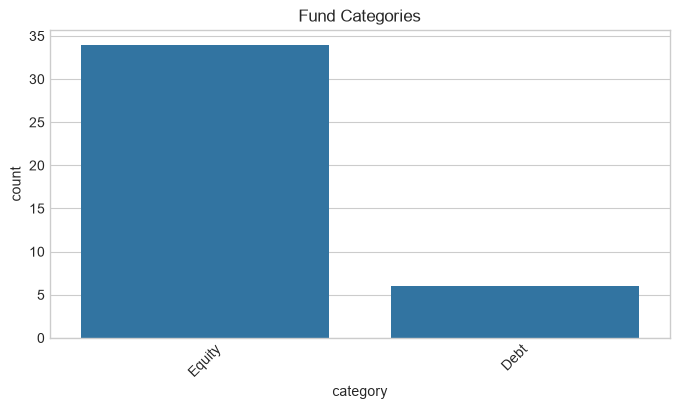

In [9]:
# Basic category distribution
category_counts = fund_master['category'].value_counts()
print(category_counts)

plt.figure(figsize=(8, 4))
sns.countplot(data=fund_master, x='category', order=category_counts.index)
plt.title('Fund Categories')
plt.xticks(rotation=45)
plt.show()


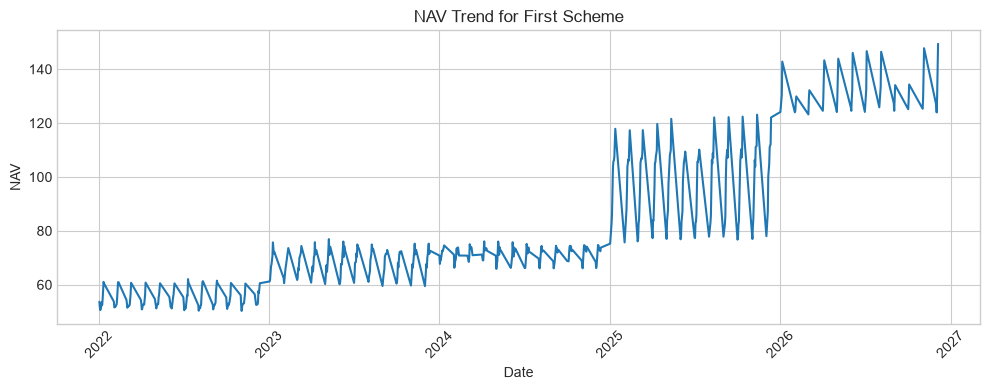

In [10]:
# Simple NAV trend example using the first scheme
sample_nav = nav_history[nav_history['amfi_code'] == fund_master['amfi_code'].iloc[0]].copy()
sample_nav = sample_nav.sort_values('date')

plt.figure(figsize=(10, 4))
plt.plot(sample_nav['date'], sample_nav['nav'])
plt.title('NAV Trend for First Scheme')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


  category  funds  avg_expense_ratio  avg_min_sip
0     Debt      6           0.668333        500.0
1   Equity     34           1.337353        500.0


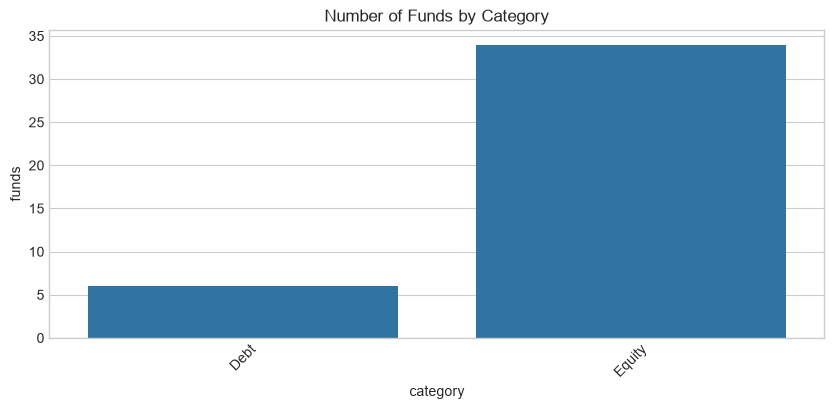

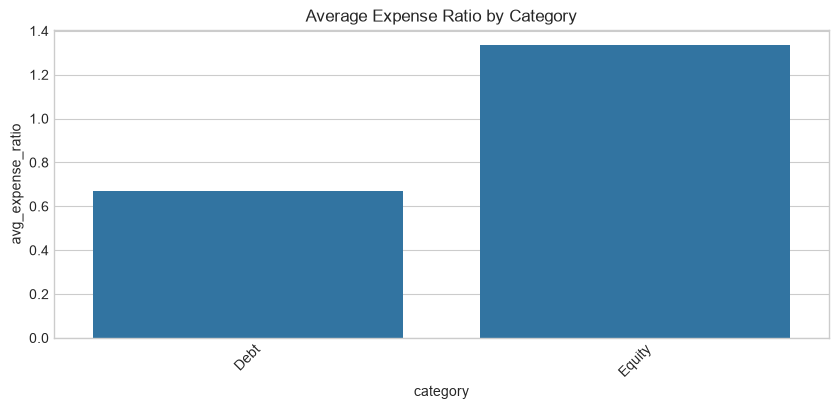

In [11]:
# Compare fund categories by count and average expense ratio
category_summary = (
    fund_master.groupby('category')
    .agg(
        funds=('scheme_name', 'count'),
        avg_expense_ratio=('expense_ratio_pct', 'mean'),
        avg_min_sip=('min_sip_amount', 'mean')
    )
    .reset_index()
)

print(category_summary)

plt.figure(figsize=(10, 4))
sns.barplot(data=category_summary, x='category', y='funds')
plt.title('Number of Funds by Category')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=category_summary, x='category', y='avg_expense_ratio')
plt.title('Average Expense Ratio by Category')
plt.xticks(rotation=45)
plt.show()


In [12]:
# Create a simple summary table for categories
category_summary = (
    fund_master.groupby('category')
    .agg(
        Fund_Count=('scheme_name', 'count'),
        Avg_Expense_Ratio=('expense_ratio_pct', 'mean'),
        Avg_Min_SIP=('min_sip_amount', 'mean'),
        Avg_Min_Lumpsum=('min_lumpsum_amount', 'mean')
    )
    .reset_index()
)

category_summary['Avg_Expense_Ratio'] = category_summary['Avg_Expense_Ratio'].round(2)
category_summary['Avg_Min_SIP'] = category_summary['Avg_Min_SIP'].round(0).astype(int)
category_summary['Avg_Min_Lumpsum'] = category_summary['Avg_Min_Lumpsum'].round(0).astype(int)

print(category_summary)


  category  Fund_Count  Avg_Expense_Ratio  Avg_Min_SIP  Avg_Min_Lumpsum
0     Debt           6               0.67          500             3000
1   Equity          34               1.34          500              974


## Risk Category Analysis

Compare funds by risk classification to understand risk distribution across the portfolio.


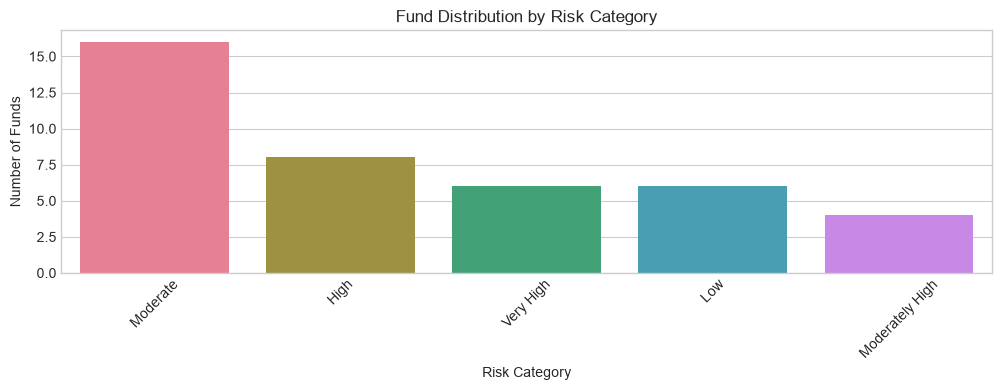

Risk Category Summary:
risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [13]:
# Risk category distribution chart
risk_counts = fund_master['risk_category'].value_counts()

plt.figure(figsize=(10, 4))
sns.countplot(data=fund_master, x='risk_category', order=risk_counts.index, palette='husl')
plt.title('Fund Distribution by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Number of Funds')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Risk Category Summary:')
print(risk_counts)


## NAV Comparison for Multiple Schemes

Track NAV trends for the top 3 schemes by fund house to see historical performance.


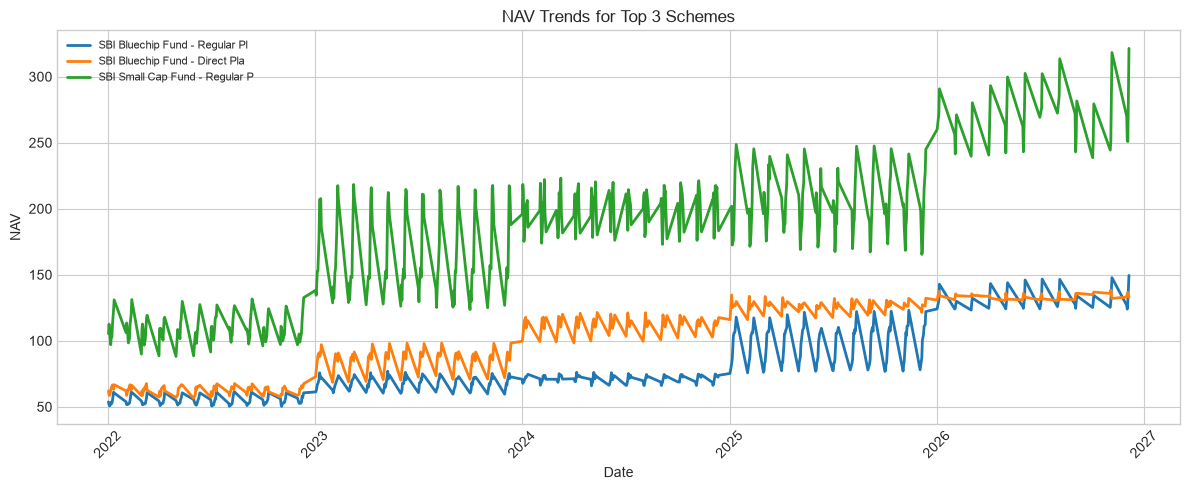

In [14]:
# Compare NAV trends for the first 3 schemes
top_schemes = fund_master['amfi_code'].head(3).tolist()

plt.figure(figsize=(12, 5))

for scheme_code in top_schemes:
    scheme_nav = nav_history[nav_history['amfi_code'] == scheme_code].copy()
    scheme_nav = scheme_nav.sort_values('date')
    
    scheme_name = fund_master[fund_master['amfi_code'] == scheme_code]['scheme_name'].values[0]
    
    plt.plot(scheme_nav['date'], scheme_nav['nav'], label=scheme_name[:30], linewidth=2)

plt.title('NAV Trends for Top 3 Schemes')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Performance Analysis: Returns by Category

Compare 3-year returns across fund categories using boxplots to see performance distribution.


In [15]:
# Load performance data and create boxplot
performance = pd.read_csv(processed_dir / 'cleaned_07_scheme_performance.csv')

# Merge performance with category information
perf_with_category = performance.merge(
    fund_master[['amfi_code', 'category']], 
    on='amfi_code', 
    how='left'
)

# Create boxplot for 3-year returns by category
plt.figure(figsize=(10, 5))
sns.boxplot(data=perf_with_category, x='category', y='return_3yr_pct', palette='Set2')
plt.title('3-Year Return Distribution by Fund Category')
plt.xlabel('Category')
plt.ylabel('3-Year Return (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics
print('3-Year Return Statistics by Category:')
print(perf_with_category.groupby('category')['return_3yr_pct'].describe())


ValueError: Could not interpret value `category` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>